In [1]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image, display
from langchain_chroma import Chroma
from langchain_core.documents import Document
import pandas as pd
import json
import requests
import xml.etree.ElementTree as ET
from datetime import date
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langsmith import traceable

/Users/kavinseralathan/Agent/.venv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
load_dotenv()

os.environ.get("OPENAI_API_KEY")
os.environ.get("LANGSMITH_API_KEY")

llm = ChatOpenAI(model="gpt-5.4-mini", temperature=0.7, api_key=os.environ.get("OPENAI_API_KEY"))

# Load once at module level — available to all functions
with open("taxonomy.json", "r") as f:
    taxonomy = json.load(f)

In [3]:
import os

load_dotenv()

# Enable LangSmith tracing (must run before LLM / LangGraph runs)
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGSMITH_TRACING"] = "true"

# Project name in the LangSmith UI
os.environ["LANGSMITH_PROJECT"] = "resolv-complaint-system"
# Optional legacy alias — harmless if unset
if os.environ.get("LANGSMITH_API_KEY") and not os.environ.get("LANGCHAIN_API_KEY"):
    os.environ["LANGCHAIN_API_KEY"] = os.environ["LANGSMITH_API_KEY"]

# Sanity check (optional — remove after it works)
assert os.environ.get("LANGSMITH_API_KEY") or os.environ.get("LANGCHAIN_API_KEY"), "Set LANGSMITH_API_KEY in .env"

# Graph State


In [4]:
class State(TypedDict):
    complaint_id: str
    issue: str
    sub_issue: str
    product: str
    sub_product: str
    narrative: str
    valid_issue: str
    valid_sub_issue: str
    valid_product: str
    valid_sub_product: str
    confidence: float
    root_cause: str
    severity: int
    severity_explanation: str
    compliance: int
    compliance_explanation: str
    applicable_regulation: str
    citation: str
    combined_results: str
    needs_human_review: bool
    review_reasons: list[str]
    team: str
    team_explanation: str
    priority: str
    sla_days: int
    sla_deadline: str
    remediation_steps: str
    preventative_recommendations: str
    customer_email: str
    reflection_feedback: list[str]
    reflection_score: int
    reflection_passed: bool
    reflection_attempts: int        


class ProductOutput(BaseModel):
    valid_product: str = Field(description="Chosen product — must be exactly one of the options")
    confidence: float

class SubProductOutput(BaseModel):
    valid_sub_product: str = Field(description="Chosen sub-product — must be exactly one of the options")
    confidence: float

class IssueOutput(BaseModel):
    valid_issue: str = Field(description="Chosen issue — must be exactly one of the options")
    confidence: float

class SubIssueOutput(BaseModel):
    valid_sub_issue: str = Field(description="Chosen sub-issue — must be exactly one of the options")
    confidence: float

class RootCauseOutput(BaseModel):
    root_cause: str = Field(description="Root cause analysis of the issue")

class SeverityOutput(BaseModel):
    severity: int = Field(description="Severity score from 1 to 10")
    severity_explanation: str = Field(description="Explanation justifying the severity score")


class ComplianceOutput(BaseModel):
    compliance: int = Field(description="Compliance risk score from 1 to 10")
    compliance_explanation: str = Field(description="Explanation justifying the compliance score")
    applicable_regulation: str = Field(
        description="The regulation that applies (FCRA, FDCPA, TILA, ECOA, Regulation E, RESPA, Payday Rule, UDAAP, or None)"
    )
    citation: str = Field(
        description="The specific legal citation e.g. 15 U.S.C. § 1681"
    )

class ReflectionOutput(BaseModel):
    passed: bool = Field(description="True if email is fully compliant, False if issues found")
    feedback: list[str] = Field(description="List of specific issues to fix. Empty if passed.")
    compliance_score: int = Field(description="Score 1-5. 5 = fully compliant.")

class TeamOutput(BaseModel):
    team: str = Field(description="The internal team that should handle this complaint")
    team_explanation: str = Field(description="Why this team was assigned")
    priority: str = Field(description="Priority level: P1 (critical), P2 (high), P3 (medium), P4 (low)")
    sla_days: int = Field(description="Days to resolve based on severity and compliance risk")
    sla_deadline: str = Field(description="Specific deadline e.g. 'Must respond within 1 business day'")

class ResolutionOutput(BaseModel):
    remediation_steps: str = Field(description="The step by step process for the team to resolve the issue")
    preventative_recommendations: str = Field(description="Preventative recommendations to avoid the issue in the future")

class CustomerEmailOutput(BaseModel):
    customer_email: str = Field(description="The customer email to send the resolution to")


In [5]:
response = requests.get(
    "https://www.ecfr.gov/api/search/v1/results",
    params={
        "query": "unauthorized transaction dispute investigation",
        "per_page": 3,
        "agency_slugs[]": "consumer-financial-protection-bureau"
    }
)
print(response.status_code)
print(response.json())

200
{'results': [{'starts_on': '2017-01-01', 'ends_on': None, 'type': 'Section', 'hierarchy': {'title': '12', 'subtitle': None, 'chapter': 'X', 'subchapter': None, 'part': '1016', 'subpart': 'C', 'subject_group': None, 'section': '1016.15', 'appendix': None}, 'hierarchy_headings': {'title': 'Title 12', 'subtitle': None, 'chapter': ' Chapter X', 'subchapter': None, 'part': 'Part 1016', 'subpart': 'Subpart C', 'subject_group': None, 'section': '§ 1016.15', 'appendix': None}, 'headings': {'title': 'Banks and Banking', 'subtitle': None, 'chapter': 'Bureau of Consumer Financial Protection', 'subchapter': None, 'part': 'Privacy of Consumer Financial Information (Regulation P)', 'subpart': 'Exceptions', 'subject_group': None, 'section': 'Other exceptions to notice and opt out requirements.', 'appendix': None}, 'full_text_excerpt': 'to the consumer, service, product, or <strong>transaction</strong>; (ii) To protect against or prevent actual<span class="elipsis">…</span>actual or potential frau

In [6]:
# Get the latest valid date automatically
titles_response = requests.get("https://www.ecfr.gov/api/versioner/v1/titles.json")
titles = titles_response.json()["titles"]
title_12 = next(t for t in titles if t["number"] == 12)
latest_date = title_12["up_to_date_as_of"]
print(f"Latest date: {latest_date}")

# Then use latest_date in your download loop

Latest date: 2026-04-09


In [7]:
CFPB_PARTS = {
    "1002": "ECOA",
    "1005": "Regulation_E", 
    "1006": "FDCPA",
    "1022": "FCRA",
    "1024": "RESPA",
    "1026": "TILA",
    "1041": "Payday_Rule",
}

for part_num, name in CFPB_PARTS.items():
    # Correct format from API docs — title in path, chapter and part as query params
    url = f"https://www.ecfr.gov/api/versioner/v1/full/{latest_date}/title-12.xml"
    
    response = requests.get(
        url,
        params={
            "chapter": "X",
            "part": part_num
        },
        timeout=30
    )
    
    print(f"{name}: {response.status_code} — URL: {response.url}")
    
    if response.status_code == 200:
        with open(f"/Users/kavinseralathan/Agent/Rules/cfpb_part_{part_num}_{name}.xml", "wb") as f:
            f.write(response.content)
        print(f"  ✅ Saved ({len(response.content)} bytes)")
    else:
        print(f"  ❌ Response: {response.text[:200]}")

ECOA: 200 — URL: https://www.ecfr.gov/api/versioner/v1/full/2026-04-09/title-12.xml?chapter=X&part=1002
  ✅ Saved (554247 bytes)
Regulation_E: 200 — URL: https://www.ecfr.gov/api/versioner/v1/full/2026-04-09/title-12.xml?chapter=X&part=1005
  ✅ Saved (859401 bytes)
FDCPA: 200 — URL: https://www.ecfr.gov/api/versioner/v1/full/2026-04-09/title-12.xml?chapter=X&part=1006
  ✅ Saved (231294 bytes)
FCRA: 200 — URL: https://www.ecfr.gov/api/versioner/v1/full/2026-04-09/title-12.xml?chapter=X&part=1022
  ✅ Saved (272639 bytes)
RESPA: 200 — URL: https://www.ecfr.gov/api/versioner/v1/full/2026-04-09/title-12.xml?chapter=X&part=1024
  ✅ Saved (518522 bytes)
TILA: 200 — URL: https://www.ecfr.gov/api/versioner/v1/full/2026-04-09/title-12.xml?chapter=X&part=1026
  ✅ Saved (3946903 bytes)
Payday_Rule: 200 — URL: https://www.ecfr.gov/api/versioner/v1/full/2026-04-09/title-12.xml?chapter=X&part=1041
  ✅ Saved (159935 bytes)


In [8]:
CFPB_PARTS = {
    "1002": "ECOA - Equal Credit Opportunity Act",
    "1005": "Regulation E - Electronic Fund Transfers",
    "1006": "FDCPA - Fair Debt Collection Practices Act",
    "1022": "FCRA - Fair Credit Reporting Act",
    "1024": "RESPA - Real Estate Settlement Procedures Act",
    "1026": "TILA - Truth in Lending Act",
    "1041": "Payday_Rule - Vehicle Title and High Cost Installment Loans",
}

def parse_xml_to_docs(filepath, part_num, reg_name):
    tree = ET.parse(filepath)
    root = tree.getroot()
    
    docs = []
    
    # Find all SECTION elements
    for section in root.iter():
        if section.get("TYPE") != "SECTION":
            continue
        
        section_num = section.get("N", "")
        
        # Get section heading
        head = section.find("HEAD")
        section_title = head.text.strip() if head is not None and head.text else ""
        
        # Get all paragraph text
        paragraphs = []
        for p in section.iter("P"):
            if p.text:
                paragraphs.append(p.text.strip())
            # Also get text inside child elements like <I>
            full_text = "".join(p.itertext()).strip()
            if full_text and full_text not in paragraphs:
                paragraphs[-1] = full_text  # replace with full text including italics
        
        if not paragraphs:
            continue
        
        content = f"{section_title}\n\n" + "\n".join(paragraphs)
        
        docs.append(Document(
            page_content=content,
            metadata={
                "regulation": reg_name,
                "part": f"12 CFR Part {part_num}",
                "section": section_num,
                "section_title": section_title,
                "citation": f"12 CFR § {section_num}"
            }
        ))
    
    return docs

# Parse all downloaded XML files
all_docs = []

for part_num, reg_name in CFPB_PARTS.items():
    filename = f"/Users/kavinseralathan/Agent/Rules/cfpb_part_{part_num}_{reg_name.split(' - ')[0].replace(' ', '_')}.xml"
    
    try:
        docs = parse_xml_to_docs(filename, part_num, reg_name)
        all_docs.extend(docs)
        print(f"✅ {reg_name}: {len(docs)} sections parsed")
    except Exception as e:
        print(f"❌ {reg_name}: {e}")

print(f"\nTotal sections: {len(all_docs)}")

# Preview first doc
if all_docs:
    print("\n--- PREVIEW ---")
    print(f"Section: {all_docs[0].metadata['citation']}")
    print(f"Content preview: {all_docs[0].page_content[:300]}")

✅ ECOA - Equal Credit Opportunity Act: 30 sections parsed
✅ Regulation E - Electronic Fund Transfers: 27 sections parsed
✅ FDCPA - Fair Debt Collection Practices Act: 15 sections parsed
✅ FCRA - Fair Credit Reporting Act: 36 sections parsed
✅ RESPA - Real Estate Settlement Procedures Act: 29 sections parsed
✅ TILA - Truth in Lending Act: 58 sections parsed
✅ Payday_Rule - Vehicle Title and High Cost Installment Loans: 10 sections parsed

Total sections: 205

--- PREVIEW ---
Section: 12 CFR § 1002.1
Content preview: § 1002.1 Authority, scope and purpose.

(a) Authority and scope. This part, known as Regulation B, is issued by the Bureau of Consumer Financial Protection (Bureau) pursuant to title VII (Equal Credit Opportunity Act) of the Consumer Credit Protection Act, as amended (15 U.S.C. 1601 et seq.). Except


In [9]:
# Split sections into smaller chunks for better retrieval
splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50
)

chunked_docs = []
for doc in all_docs:
    chunks = splitter.split_text(doc.page_content)
    for chunk in chunks:
        chunked_docs.append(Document(
            page_content=chunk,
            metadata=doc.metadata  # preserve section, citation, regulation metadata
        ))

print(f"Total chunks after splitting: {len(chunked_docs)}")

# Build and persist vector store
embeddings = OpenAIEmbeddings()
regulation_store = Chroma.from_documents(
    chunked_docs,
    embeddings,
    collection_name="cfpb_regulations",
    persist_directory="./regulation_index"
)

print("✅ Vector store built and saved to ./regulation_index")

# Quick sanity check — test a retrieval
test_query = "debt collector calling before 8am harassment prohibited"
results = regulation_store.similarity_search(test_query, k=3)

print(f"\n--- RETRIEVAL TEST ---")
print(f"Query: {test_query}")
for r in results:
    print(f"\nCitation: {r.metadata['citation']}")
    print(f"Regulation: {r.metadata['regulation']}")
    print(f"Text: {r.page_content[:200]}")

Total chunks after splitting: 4803
✅ Vector store built and saved to ./regulation_index

--- RETRIEVAL TEST ---
Query: debt collector calling before 8am harassment prohibited

Citation: 12 CFR § 1006.6
Regulation: FDCPA - Fair Debt Collection Practices Act
Text: (i) At any unusual time, or at a time that the debt collector knows or should know is inconvenient to the consumer. In the absence of the debt collector's knowledge of circumstances to the contrary, a

Citation: 12 CFR § 1006.6
Regulation: FDCPA - Fair Debt Collection Practices Act
Text: (i) At any unusual time, or at a time that the debt collector knows or should know is inconvenient to the consumer. In the absence of the debt collector's knowledge of circumstances to the contrary, a

Citation: 12 CFR § 1006.14
Regulation: FDCPA - Fair Debt Collection Practices Act
Text: (b) Repeated or continuous telephone calls or telephone conversations—(1) In general. In connection with the collection of a debt, a debt collector must not p

# Nodes

In [ ]:
@traceable
def validate_issue(state: State):

    product_llm = llm.with_structured_output(ProductOutput)
    sub_product_llm = llm.with_structured_output(SubProductOutput)
    issue_llm = llm.with_structured_output(IssueOutput)
    sub_issue_llm = llm.with_structured_output(SubIssueOutput)
    
    # Step 1 — Product (~10 normalized options)
    products = list(taxonomy.keys())
    product_result = product_llm.invoke(
        f"Given the following narrative:\n{state['narrative']}\n\nAnd the classifications:\nProduct: {state['product']}\nSub-product: {state['sub_product']}\nIssue: {state['issue']}\nSub-issue: {state['sub_issue']}\n\nAre these classifications appropriate for the narrative? If not, suggest the most accurate options from this list: {products}."
    )
    chosen_product = product_result.valid_product

    # Step 2 — Sub-product (4-12 options)
    sub_products = list(taxonomy[chosen_product].keys())
    sub_product_result = sub_product_llm.invoke(
        f"Given the following narrative:\n{state['narrative']}\n\nAnd the classifications:\nProduct: {state['product']}\nSub-product: {state['sub_product']}\nIssue: {state['issue']}\nSub-issue: {state['sub_issue']}\n\nAre these classifications appropriate for the narrative? If not, suggest the most accurate options from this list: {sub_products}."
    )
    chosen_sub_product = sub_product_result.valid_sub_product

    # Step 3 — Issue (4-16 options scoped to sub-product)
    issues = list(taxonomy[chosen_product][chosen_sub_product].keys())
    issue_result = issue_llm.invoke(
        f"Given the following narrative:\n{state['narrative']}\n\nAnd the classifications:\nProduct: {state['product']}\nSub-product: {state['sub_product']}\nIssue: {state['issue']}\nSub-issue: {state['sub_issue']}\n\nAre these classifications appropriate for the narrative? If not, suggest the most accurate options from this list: {issues}."
    )
    chosen_issue = issue_result.valid_issue

    # Step 4 — Sub-issue (2-6 options)
    sub_issues = taxonomy[chosen_product][chosen_sub_product][chosen_issue]
    sub_issue_result = sub_issue_llm.invoke(
        f"Given the following narrative:\n{state['narrative']}\n\nAnd the classifications:\nProduct: {state['product']}\nSub-product: {state['sub_product']}\nIssue: {state['issue']}\nSub-issue: {state['sub_issue']}\n\nAre these classifications appropriate for the narrative? If not, suggest the most accurate options from this list: {sub_issues}."
    )

    return {
        "valid_product": chosen_product,
        "valid_sub_product": chosen_sub_product,
        "valid_issue": chosen_issue,
        "valid_sub_issue": sub_issue_result.valid_sub_issue,
        "confidence": min(
            product_result.confidence,
            sub_product_result.confidence,
            issue_result.confidence,
            sub_issue_result.confidence
        )
    }

@traceable
def root_cause_analysis(state: State):
    structured_llm = llm.with_structured_output(RootCauseOutput)
    prompt = f"""
    Analyze the root cause of the issue: {state['valid_issue']} 
    for product: {state['valid_product']} 
    based on the narrative: {state['narrative']}
    """
    result = structured_llm.invoke(prompt)
    return {"root_cause": result.root_cause}

@traceable
def severity_assessment(state: State):
    structured_llm = llm.with_structured_output(SeverityOutput)

    prompt = f"""You are a financial complaint severity analyst. Rate the severity of this consumer complaint on a scale of 1-10.
    SEVERITY RULES:

    High severity (8-10) — serious financial harm, urgent action needed:
    - Fraud, scam, or identity theft
    - Unauthorized transactions or account access
    - Account frozen or funds inaccessible
    - Foreclosure or repossession
    - Incorrect credit report information causing financial damage
    - Large financial loss (hundreds or thousands of dollars)
    - Repeated unresolved issues causing ongoing harm
    - Legal threats or debt collection misconduct

    Medium severity (4-7) — real problem but manageable:
    - Unexpected or incorrect fees
    - Payment processing errors
    - Billing disputes
    - Trouble opening, managing, or closing an account
    - Poor customer service causing moderate inconvenience
    - Loan servicing problems
    - Application delays

    Low severity (1-3) — minor inconvenience, no significant financial harm:
    - Confusing or misleading advertising
    - Minor rewards or promotional issues
    - General dissatisfaction with service
    - Small disclosure complaints without direct harm
    - Minor communication frustrations
    
    ADDITIONAL FACTORS that increase severity:
    - Consumer mentions being a Servicemember or veteran (+1)
    - Issue has been unresolved for more than 30 days (+1)
    - Consumer mentions attorney, lawsuit, or regulator (+2)
    - Consumer mentions credit score impact (+1)
    - Consumer expresses significant emotional distress (+1)
    
    COMPLAINT DETAILS:
    Product: {state['valid_product']}
    Sub-product: {state['valid_sub_product']}
    Issue: {state['valid_issue']}
    Sub-issue: {state['valid_sub_issue']}
    Narrative: {state['narrative']}
    
    Rate the severity 1-10 and explain your reasoning in 1-2 sentences.
    """
    result = structured_llm.invoke(prompt)
    return {"severity": result.severity, "severity_explanation": result.severity_explanation}

@traceable
def compliance_assessment(state: State):
    structured_llm = llm.with_structured_output(ComplianceOutput)
    
    # RAG — retrieve relevant regulation sections
    query = f"{state['valid_issue']} {state['valid_sub_issue']} {state['narrative']}"
    relevant_regs = regulation_store.similarity_search(query, k=4)
    
    reg_context = "\n\n---\n\n".join([
        f"Regulation: {r.metadata['regulation']}\n"
        f"Citation: {r.metadata['citation']}\n"
        f"Text: {r.page_content}"
        for r in relevant_regs
    ])
    
    result = structured_llm.invoke(
        f"""You are a financial compliance analyst. Assess the regulatory risk of this consumer complaint using the official CFPB regulation sections below.
        
        OFFICIAL CFPB REGULATIONS: {reg_context}

        COMPLAINT DETAILS:
        Product: {state['valid_product']}
        Sub-product: {state['valid_sub_product']}
        Issue: {state['valid_issue']}
        Sub-issue: {state['valid_sub_issue']}
        Narrative: {state['narrative']}

        COMPLIANCE RISK SCALE:
        High (8-10): Specific regulation above was likely violated
        Medium (4-7): Potential violation, regulatory gray area
        Low (1-3): No clear regulatory violation

        Rate compliance risk 1-10. Cite the specific regulation and section 
        from above. Explain in 1-2 sentences."""
    )
    
    return {
        "compliance": result.compliance,
        "compliance_explanation": result.compliance_explanation,
        "applicable_regulation": result.applicable_regulation,
        "citation": result.citation
    }

@traceable
def aggregate_results(state: State):
    combined = (
        f"Issue: {state['valid_issue']}\n"
        f"Product: {state['valid_product']}\n"
        f"Root Cause: {state['root_cause']}\n"
        f"Severity: {state['severity']}/10 — {state['severity_explanation']}\n"
        f"Compliance Risk: {state['compliance']}/10 — {state['compliance_explanation']}"
    )
    return {"combined_results": combined}

@traceable
def assign_role(state: State):
    structured_llm = llm.with_structured_output(TeamOutput)
    result = structured_llm.invoke(
        f"""Assign the correct internal team, priority level, and SLA 
        deadline for this consumer complaint.

        COMPLAINT DETAILS:
        Product: {state['valid_product']}
        Sub-product: {state['valid_sub_product']}
        Issue: {state['valid_issue']}
        Sub-issue: {state['valid_sub_issue']}
        Severity: {state['severity']}/10
        Compliance Risk: {state['compliance']}/10
        Applicable Regulation: {state['applicable_regulation']}
        Narrative: {state['narrative']}

        INTERNAL TEAMS:
        - Billing Team → billing disputes, duplicate charges, unexpected fees
        - Fraud Team → fraud, scam, unauthorized transactions, identity theft
        - Compliance Team → credit reporting issues, regulatory violations, 
        Servicemember complaints
        - Customer Service → account management, communication issues, closures
        - Engineering Team → systemic issues flagged as affecting multiple consumers
        - Loans Team → mortgage, student loan, vehicle loan, debt collection issues

        PRIORITY RULES:
        P1 (Critical) → severity 8-10 OR compliance 8-10 OR Servicemember tag
        P2 (High)     → severity 6-7 OR compliance 6-7
        P3 (Medium)   → severity 4-5 OR compliance 4-5
        P4 (Low)      → severity 1-3 AND compliance 1-3

        SLA RULES — assign based on highest applicable rule:
        - Servicemember complaint → 1 business day (MLA requirement)
        - P1 + compliance risk 8-10 → 1 business day
        - P1 + compliance risk 6-7 → 3 business days
        - P2 → 5 business days
        - P3 → 10 business days
        - P4 → 15 business days (CFPB maximum response window)
        - NEVER assign more than 15 days (CFPB requires response within 15 days)

        Format sla_deadline as: "Must respond within X business day(s) — by [reason]"
        Example: "Must respond within 1 business day — P1 FCRA compliance risk"
        """
    )
    return {
        "team": result.team,
        "team_explanation": result.team_explanation,
        "priority": result.priority,
        "sla_days": result.sla_days,
        "sla_deadline": result.sla_deadline
    }

@traceable
def review_router(state: State):
    reasons = []
    
    if state["confidence"] < 0.70:
        reasons.append(f"Low confidence: {state['confidence']:.0%}")
    
    if state["severity"] >= 8:
        reasons.append(f"High severity: {state['severity']}/10")
    
    if state["compliance"] >= 8:
        reasons.append(f"High compliance risk: {state['compliance']}/10")
    
    needs_review = len(reasons) > 0
    
    return {
        "needs_human_review": needs_review,
        "review_reasons": reasons
    }

@traceable
def route_decision(state: State):
    if state["needs_human_review"]:
        return "human_input"      # pause for review
    else:
        return "auto_proceed"     # skip straight to resolution

@traceable
def human_input(state: State):
    print(f"✅ Human approved complaint for team: {state['team']}")
    return {}

@traceable
def create_resolution(state: State):
    structured_llm = llm.with_structured_output(ResolutionOutput)
    result = structured_llm.invoke(
        f"Based on the following issue and product, create a resolution to the issue.\n"
        f"Issue: {state['valid_issue']}\nProduct: {state['valid_product']}\nNarrative: {state['narrative']}"
    )
    return {"remediation_steps": result.remediation_steps, "preventative_recommendations": result.preventative_recommendations}

@traceable
def create_customer_email(state: State):
    structured_llm = llm.with_structured_output(CustomerEmailOutput)
    
    # Build feedback section if this is a retry
    feedback_section = ""
    if state.get("reflection_feedback"):
        feedback_section = f"""PREVIOUS EMAIL FAILED COMPLIANCE REVIEW. YOU MUST FIX THESE SPECIFIC ISSUES: {chr(10).join(f"- {f}" for f in state['reflection_feedback'])}

        Do not return the same email. Fix all issues listed above.
        """
    
    query = f"{state['valid_issue']} {state['valid_sub_issue']} {state['narrative']}"
    relevant_regs = regulation_store.similarity_search(query, k=4)
    
    reg_context = "\n\n---\n\n".join([
        f"Regulation: {r.metadata['regulation']}\n"
        f"Citation: {r.metadata['citation']}\n"
        f"Text: {r.page_content}"
        for r in relevant_regs
    ])

    result = structured_llm.invoke(
        f"""You are a compliance officer at a fintech company writing a 
        regulatory-compliant customer response email. Your email will be 
        reviewed by a compliance checker before it is sent.

        OFFICIAL CFPB REGULATIONS (use these to cite consumer rights and timelines):
        {reg_context}

        COMPLAINT DETAILS:
        Product: {state['valid_product']}
        Issue: {state['valid_issue']}
        Sub-issue: {state['valid_sub_issue']}
        Severity: {state['severity']}/10
        Applicable Regulation: {state['applicable_regulation']}
        Citation: {state['citation']}
        Case Reference: {state['complaint_id']}
        Assigned Team: {state['team']}
        Narrative: {state['narrative']}
        {feedback_section}

        MANDATORY REQUIREMENTS — every single one must appear in the email:

        1. CASE REFERENCE — include "Case Reference: {state['complaint_id']}" 
        in the subject line and opening paragraph

        2. REGULATORY TIMELINE — state the exact investigation window:
        - FCRA: "within 30 days of receiving your dispute (45 days if 
        you provide additional information during the investigation)"
        - FDCPA: "within 5 days of this notice"
        - TILA: "within 2 billing cycles, not to exceed 90 days"
        - Reg E: "within 10 business days, with provisional credit 
        applied if investigation exceeds that period"
        Do NOT use vague language like "as soon as possible" or 
        "allow us time"

        3. CONSUMER RIGHTS — explicitly state the consumer's rights under 
        {state['citation']} in plain language. Reference the regulation 
        by name (e.g. "Under the Fair Credit Reporting Act (FCRA)...")

        4. CONTACT INFORMATION — include these three labeled placeholders:
        [Customer Service Phone: __________]
        [Customer Service Email: __________]  
        [Mailing Address: __________]

        5. TONE — severity is {state['severity']}/10:
        - 8-10: Urgent, empathetic, acknowledge seriousness immediately
        - 4-7: Professional, clear, helpful
        - 1-3: Friendly, informative

        6. OUTCOME LANGUAGE — you MUST include this exact phrase or 
        equivalent: "We cannot guarantee a specific outcome, however..."
        This protects against implying a promised result.

        ABSOLUTE PROHIBITIONS — violating any of these will cause rejection:
        - Do NOT admit liability ("we made an error", "we were wrong")
        - Do NOT promise a specific outcome ("we will remove", "we will refund")
        - Do NOT use vague timelines ("soon", "promptly", "in due course")
        - Do NOT imply the company is at fault before investigation completes

        EMAIL STRUCTURE:
        Subject: Re: Case {state['complaint_id']} — [Issue Type]
        Opening: Acknowledge complaint and case number
        Body paragraph 1: Consumer rights under applicable regulation
        Body paragraph 2: Exact regulatory timeline for resolution
        Body paragraph 3: Outcome language + what happens next
        Closing: Contact information + team sign-off"""
    )
    return {"customer_email": result.customer_email}

@traceable
def reflection_agent(state: State):
    structured_llm = llm.with_structured_output(ReflectionOutput)
    
    query = f"{state['valid_issue']} {state['valid_sub_issue']} {state['narrative']}"
    relevant_regs = regulation_store.similarity_search(query, k=4)
    
    reg_context = "\n\n---\n\n".join([
        f"Regulation: {r.metadata['regulation']}\n"
        f"Citation: {r.metadata['citation']}\n"
        f"Text: {r.page_content}"
        for r in relevant_regs
    ])
    
    result = structured_llm.invoke(
        f"""You are a regulatory compliance reviewer. Grade this customer email for compliance violations. Do NOT rewrite it — only identify issues.
        
        OFFICIAL CFPB REGULATIONS: 
        {reg_context}

        ORIGINAL COMPLAINT:
        Product: {state['valid_product']}
        Issue: {state['valid_issue']}
        Severity: {state['severity']}/10
        Applicable Regulation: {state['applicable_regulation']}
        Citation: {state['citation']}
        Complaint ID: {state['complaint_id']}
        Narrative: {state['narrative']}

        EMAIL TO GRADE:
        {state['customer_email']}

        CHECK EACH ITEM — fail if ANY are missing or violated:
        1. Admits liability or fault? → FAIL if yes
        2. Promises specific outcome? → FAIL if yes
        3. Missing timeline tied to regulation?
        - FCRA: must mention 30-day investigation window
        - FDCPA: must mention 5-day validation notice
        - TILA: must mention 2 billing cycle resolution
        - Reg E: must mention 10 business day provisional credit
        4. Missing case reference number {state['complaint_id']}? → FAIL if missing
        5. Missing contact information for follow-up? → FAIL if missing
        6. Tone inappropriate for severity {state['severity']}/10? → FAIL if yes
        7. Missing citation of consumer rights under applicable regulation? → FAIL if missing

        If ALL checks pass → passed=True, empty feedback list
        If ANY check fails → passed=False, list exactly what needs to be fixed"""
    )
    return {
        "reflection_passed": result.passed,
        "reflection_feedback": result.feedback,
        "reflection_score": result.compliance_score,
        "reflection_attempts": state.get("reflection_attempts", 0) + 1
    }

@traceable
def route_reflection(state: State):
    # Hard stop after 3 attempts to prevent infinite loop
    if state.get("reflection_attempts", 0) >= 3:
        return "end"
    if state["reflection_passed"]:
        return "end"
    return "retry"

# Build Workflow

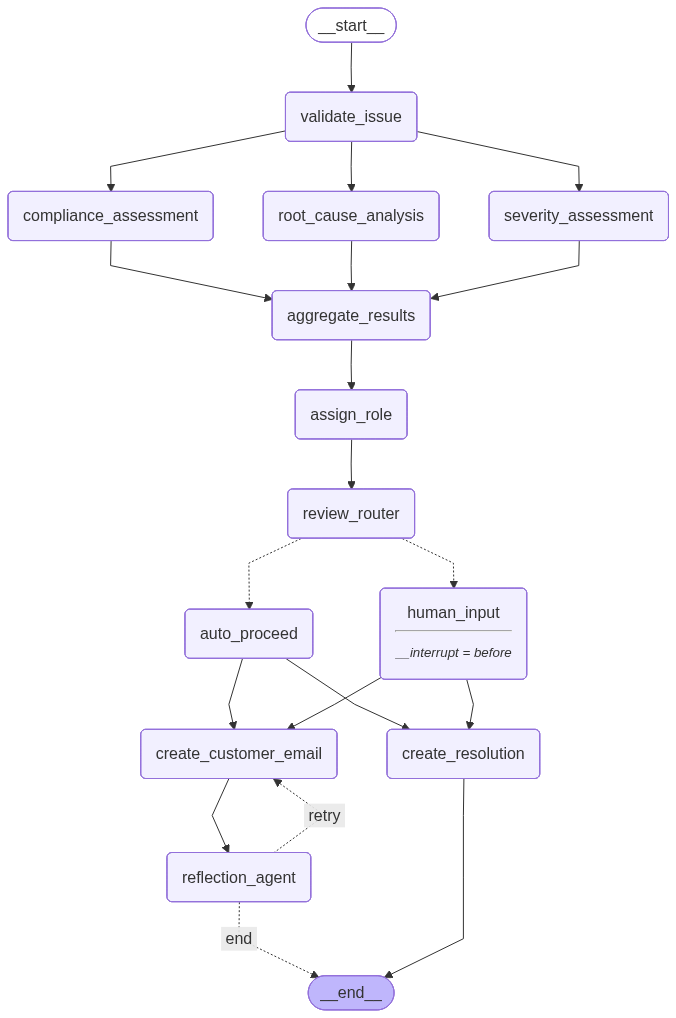

In [11]:
parallel = StateGraph(State)

parallel.add_node("validate_issue", validate_issue)
parallel.add_node("root_cause_analysis", root_cause_analysis)
parallel.add_node("severity_assessment", severity_assessment)
parallel.add_node("compliance_assessment", compliance_assessment)
parallel.add_node("aggregate_results", aggregate_results)
parallel.add_node("assign_role", assign_role)
parallel.add_node("review_router", review_router)
parallel.add_node("auto_proceed", lambda state: {})  # passthrough node
parallel.add_node("human_input", human_input)
parallel.add_node("create_resolution", create_resolution)
parallel.add_node("create_customer_email", create_customer_email)
parallel.add_node("reflection_agent", reflection_agent)

parallel.add_edge(START, "validate_issue")
parallel.add_edge("validate_issue", "root_cause_analysis")
parallel.add_edge('validate_issue', 'severity_assessment')
parallel.add_edge('validate_issue', 'compliance_assessment')
parallel.add_edge('root_cause_analysis', 'aggregate_results')
parallel.add_edge('severity_assessment', 'aggregate_results')
parallel.add_edge('compliance_assessment', 'aggregate_results')
parallel.add_edge('aggregate_results', 'assign_role')
parallel.add_edge("assign_role", "review_router")     # ← goes to router first
parallel.add_conditional_edges(
    "review_router",
    route_decision,
    {
        "human_input": "human_input",
        "auto_proceed": "auto_proceed"
    }
)
parallel.add_edge('human_input', 'create_resolution')
parallel.add_edge('human_input', 'create_customer_email')
parallel.add_edge("auto_proceed", "create_resolution")
parallel.add_edge("auto_proceed", "create_customer_email")
parallel.add_edge("create_customer_email", "reflection_agent")
parallel.add_conditional_edges(
    "reflection_agent",
    route_reflection,
    {
        "retry": "create_customer_email",  # loop back
        "end": END
    }
)
parallel.add_edge('create_customer_email', END)
parallel.add_edge('create_resolution', END)

memory = MemorySaver()

compiled_parallel = parallel.compile(checkpointer=memory, interrupt_before=["human_input"])

display(Image(compiled_parallel.get_graph().draw_mermaid_png()))

# Invoke

In [12]:
config = {"configurable": {"thread_id": "complaint_001"}}

# First run — goes until interrupt
for node in compiled_parallel.stream({
    "issue": "Incorrect information on your report",
    "product": "Credit reporting or other personal consumer reports",
    "narrative": "Kindly address this issue on my credit report. I assert that this account is not mine and believe it to be fraudulent. I urge you to correct this mistake and have provided supporting documents for verification.",
    "complaint_id": "8113747"
}, config=config):
    print(node)

# Check if pipeline paused
state = compiled_parallel.get_state(config)

if state.next == ("human_input",):
    print("\n⚠️  HUMAN REVIEW REQUIRED")
    print(f"Reasons: {state.values['review_reasons']}")
    print(f"Issue: {state.values['valid_issue']}")
    print(f"Severity: {state.values['severity']}/10")
    print(f"Severity Explanation: {state.values['severity_explanation']}")
    print(f"Compliance: {state.values['compliance']}/10")
    print(f"Compliance Explanation: {state.values['compliance_explanation']}")
    print(f"Team: {state.values['team']}")
    
    decision = input("\n[A]pprove or [E]dit & Approve? ").strip().lower()
    
    if decision == "e":
        updates = {}
        new_severity = input(f"New severity (1-10) or Enter to skip: ").strip()
        new_compliance = input(f"New compliance (1-10) or Enter to skip: ").strip()
        new_team = input(f"New team or Enter to skip: ").strip()
        
        if new_severity: updates["severity"] = int(new_severity)
        if new_compliance: updates["compliance"] = int(new_compliance)
        if new_team: updates["team"] = new_team
        
        if updates:
            compiled_parallel.update_state(config, updates)
            print(f"✏️  Updated: {updates}")
    
    # Resume pipeline
    print("\n▶️  Resuming...")
    for node in compiled_parallel.stream(None, config=config):
        print(node)

else:
    print("\n✅ Auto-processed — no review needed")

{'validate_issue': {'valid_product': 'Credit reporting or other personal consumer reports', 'valid_sub_product': 'Credit reporting', 'valid_issue': 'Incorrect information on your report', 'valid_sub_issue': 'Information belongs to someone else', 'confidence': 0.98}}
{'severity_assessment': {'severity': 9, 'severity_explanation': 'This is a high-severity credit reporting complaint because the consumer says an account on the report is not theirs and may be fraudulent, which can indicate identity theft or incorrect information causing financial harm. Errors belonging to someone else can materially affect creditworthiness and require urgent correction.'}}
{'root_cause_analysis': {'root_cause': "The dispute indicates that the consumer believes an account appearing on the credit report does not belong to them and is likely the result of identity theft or a data furnishing/matching error. The root cause is an incorrect account association on the consumer's credit file, where information was r